In [1]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.10.0+cu128
True
Tesla T4


In [2]:

# ─────────────────────────────────────────────
# SECTION 0: Imports
# ─────────────────────────────────────────────
import gc
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")


In [3]:
 
df = pd.read_csv("/kaggle/input/datasets/mohamedismal/water-data/Combined_dataset.csv")
 

In [4]:
print("Shape:", df.shape)
df.head()
df.info()
 

Shape: (2827977, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2827977 entries, 0 to 2827976
Data columns (total 14 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   Country                           object 
 1   Area                              object 
 2   Waterbody Type                    object 
 3   Date                              object 
 4   Ammonia (mg/l)                    float64
 5   Biochemical Oxygen Demand (mg/l)  float64
 6   Dissolved Oxygen (mg/l)           float64
 7   Orthophosphate (mg/l)             float64
 8   pH (ph units)                     float64
 9   Temperature (cel)                 float64
 10  Nitrogen (mg/l)                   float64
 11  Nitrate (mg/l)                    float64
 12  CCME_Values                       float64
 13  CCME_WQI                          object 
dtypes: float64(9), object(5)
memory usage: 302.1+ MB


In [5]:
df.isnull().sum()

Country                             0
Area                                0
Waterbody Type                      0
Date                                0
Ammonia (mg/l)                      0
Biochemical Oxygen Demand (mg/l)    0
Dissolved Oxygen (mg/l)             0
Orthophosphate (mg/l)               0
pH (ph units)                       0
Temperature (cel)                   0
Nitrogen (mg/l)                     0
Nitrate (mg/l)                      0
CCME_Values                         0
CCME_WQI                            0
dtype: int64

In [6]:
df["CCME_Values"].describe()


count    2.827977e+06
mean     8.504668e+01
std      1.764665e+01
min      3.130414e+01
25%      7.715349e+01
50%      9.059609e+01
75%      1.000000e+02
max      1.000000e+02
Name: CCME_Values, dtype: float64

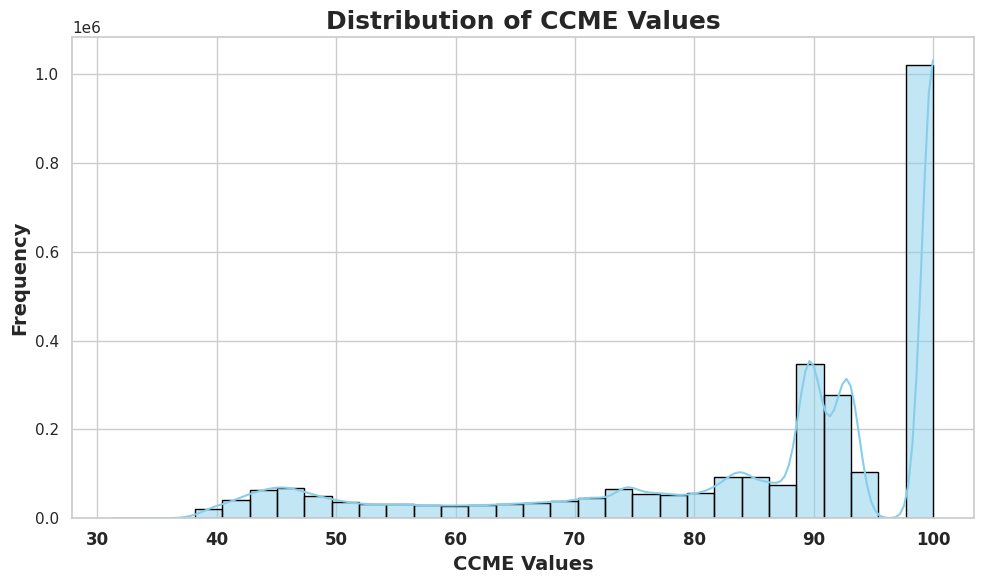

In [7]:

plt.figure(figsize=(10, 6))
sns.histplot(df["CCME_Values"].dropna(), bins=30, kde=True, color="skyblue", edgecolor="black")
plt.title("Distribution of CCME Values", fontsize=18, fontweight="bold")
plt.xlabel("CCME Values", fontsize=14, fontweight="bold")
plt.ylabel("Frequency", fontsize=14, fontweight="bold")
plt.xticks(fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()



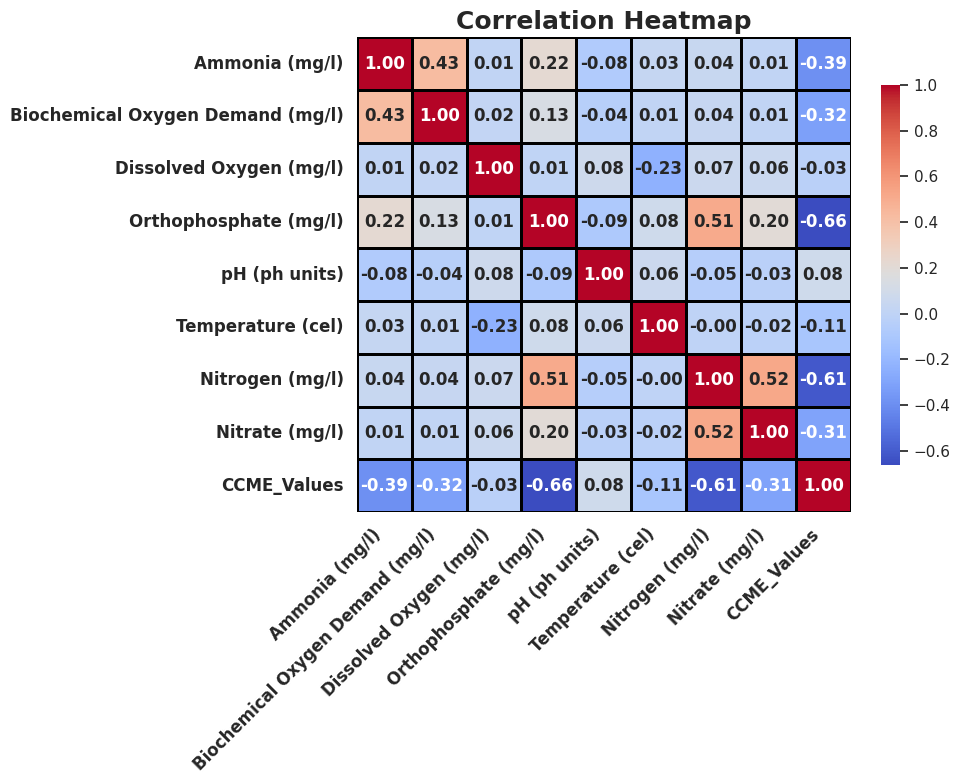

In [8]:
 
# --- Correlation Heatmap ---
corr_data = df.select_dtypes(include="number").corr()
plt.figure(figsize=(10, 8))
ax = sns.heatmap(corr_data, annot=True, cmap="coolwarm", fmt=".2f",
                 annot_kws={"size": 12, "weight": "bold"},
                 linewidths=1, linecolor="black", cbar_kws={"shrink": 0.8})
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, fontweight="bold",
                   rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), fontsize=12, fontweight="bold")
plt.title("Correlation Heatmap", fontsize=18, fontweight="bold")
plt.tight_layout(); plt.show()


In [9]:
# ─────────────────────────────────────────────
# SECTION 2: Cleaning & Feature Engineering
# ─────────────────────────────────────────────
df["Date"]        = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
df["CCME_Values"] = pd.to_numeric(df["CCME_Values"], errors="coerce")
df["Year"]        = df["Date"].dt.year
df["Month"]       = df["Date"].dt.month

# --- Valid ranges filter ---
valid_ranges = {
    "Ammonia (mg/l)": (0, 20),
    "Biochemical Oxygen Demand (mg/l)": (0, 50),
    "Dissolved Oxygen (mg/l)": (2, 30),
    "Orthophosphate (mg/l)": (0, 10),
    "pH (ph units)": (4, 11),
    "Temperature (cel)": (0, 60),
    "Nitrogen (mg/l)": (0, 50),
    "Nitrate (mg/l)": (0, 100),
    "CCME_Values": (0, 100)
}
mask_valid = pd.Series(True, index=df.index)
for col, (low, high) in valid_ranges.items():
    mask_valid &= df[col].between(low, high, inclusive="both")

df_clean = df[mask_valid].copy().drop_duplicates()
print(f"After cleaning: {df_clean.shape[0]} rows")


After cleaning: 2724675 rows


In [10]:
# --- Waterbody Type grouping ---
df_clean['Waterbody Type'] = df_clean['Waterbody Type'].replace({
    'Marine': 'Coastal/Marine', 'Sea Water': 'Coastal/Marine',
    'Coastal': 'Coastal/Marine', 'Estuarine': 'Coastal/Marine',
    'Sewage': 'Wastewater', 'Effluent': 'Wastewater',
    'Canal': 'Artificial', 'Drainage': 'Artificial',
    'Bay': 'Minor Waterbodies', 'Artificial': 'Minor Waterbodies',
    'Transitional': 'Minor Waterbodies'
})

# ── NEW: Sin/Cos encoding للشهر (Seasonality Awareness) ──────────────────
df_clean['Month_sin'] = np.sin(2 * np.pi * df_clean['Month'] / 12)
df_clean['Month_cos'] = np.cos(2 * np.pi * df_clean['Month'] / 12)

df_encoded = pd.get_dummies(df_clean, columns=['Waterbody Type'], dtype="int")
print("Columns after encoding:", df_encoded.shape[1])



Columns after encoding: 23


In [11]:
# ─────────────────────────────────────────────
# SECTION 3: Train / Val / Test Split (Area-wise)
# ─────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


df_encoded['Date'] = pd.to_datetime(df_encoded['Date'], dayfirst=True, errors='coerce')
df_encoded = df_encoded.sort_values(by=['Area', 'Date']).reset_index(drop=True)

unique_areas = df_encoded['Area'].unique()
np.random.seed(42)
np.random.shuffle(unique_areas)

train_size = int(len(unique_areas) * 0.70)
val_size   = int(len(unique_areas) * 0.15)

train_areas = unique_areas[:train_size]
val_areas   = unique_areas[train_size:train_size + val_size]
test_areas  = unique_areas[train_size + val_size:]

df_train_final = df_encoded[df_encoded['Area'].isin(train_areas)].copy()
df_val_final   = df_encoded[df_encoded['Area'].isin(val_areas)].copy()
df_test_final  = df_encoded[df_encoded['Area'].isin(test_areas)].copy()

print(f"Train: {len(df_train_final)} | Val: {len(df_val_final)} | Test: {len(df_test_final)}")


Using device: cuda
Train: 1931177 | Val: 390568 | Test: 402930


In [12]:
# ─────────────────────────────────────────────
# SECTION 4: Preprocessing
# ─────────────────────────────────────────────
DROP_COLS = ["CCME_WQI", "Country", "Area", "Date", "Year", "CCME_Values", "Month"]

def extract_X_y(df):
    X_df = df.drop(columns=DROP_COLS, errors='ignore')
    y_df = df["CCME_Values"].values.astype(np.float32)
    return X_df, y_df

X_train, y_train = extract_X_y(df_train_final)
X_val,   y_val   = extract_X_y(df_val_final)
X_test,  y_test  = extract_X_y(df_test_final)

# Clean column names
def clean_cols(df):
    df.columns = [c.replace(' ', '_').replace('/', '_')
                   .replace('(', '').replace(')', '') for c in df.columns]
    return df

X_train = clean_cols(X_train)
X_val   = clean_cols(X_val)
X_test  = clean_cols(X_test)

# ✅ FIX: Use reindex to safely align columns with train set.
# This handles cases where val/test splits are missing certain one-hot
# categories that exist in train (fills missing columns with 0).
X_val  = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"Train columns : {X_train.shape[1]}")
print(f"Val   columns : {X_val.shape[1]}  (aligned to train)")
print(f"Test  columns : {X_test.shape[1]}  (aligned to train)")

num_features = [
    "Ammonia_mg_l", "Biochemical_Oxygen_Demand_mg_l", "Dissolved_Oxygen_mg_l",
    "Orthophosphate_mg_l", "pH_ph_units", "Temperature_cel",
    "Nitrogen_mg_l", "Nitrate_mg_l"
]
cat_features = [c for c in X_train.columns if c not in num_features]

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('pw', PowerTransformer(method='yeo-johnson')),
        ('sc', StandardScaler())
    ]), num_features),
    ('cat', 'passthrough', cat_features)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)
print(f"Feature dim after preprocessing: {X_train.shape[1]}")
print(f"Feature dim after preprocessing: {X_train_proc.shape[1]}")


Train columns : 16
Val   columns : 16  (aligned to train)
Test  columns : 16  (aligned to train)
Feature dim after preprocessing: 16
Feature dim after preprocessing: 16


In [13]:
# ─────────────────────────────────────────────
# SECTION 5: Sliding Window Sequences
# ─────────────────────────────────────────────
SEQ_LEN = 8

def create_sequences(X_proc, y_data, areas_df, seq_length=8, stride=3):
    all_x, all_y = [], []
    areas_vals = areas_df['Area'].values
    y_vals     = y_data.values if hasattr(y_data, 'values') else y_data

    for area in tqdm(areas_df['Area'].unique(), desc="Windowing", unit="area"):
        mask    = (areas_vals == area)
        X_area  = X_proc[mask]
        y_area  = y_vals[mask]
        if len(X_area) > seq_length:
            for start in range(0, len(X_area) - seq_length + 1, stride):
                all_x.append(X_area[start:start + seq_length])
                all_y.append(y_area[start + seq_length - 1])

    return np.array(all_x, dtype=np.float32), np.array(all_y, dtype=np.float32)

X_train_seq, y_train_seq = create_sequences(X_train_proc, y_train, df_train_final,
                                             seq_length=SEQ_LEN, stride=4)
X_val_seq,   y_val_seq   = create_sequences(X_val_proc,   y_val,   df_val_final,
                                             seq_length=SEQ_LEN, stride=1)
X_test_seq,  y_test_seq  = create_sequences(X_test_proc,  y_test,  df_test_final,
                                             seq_length=SEQ_LEN, stride=1)

print(f"Train seq: {X_train_seq.shape} | Val: {X_val_seq.shape} | Test: {X_test_seq.shape}")


# ── Save sequences to disk ──
import joblib
joblib.dump(
    (X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq),
    "sequences.pkl"
)
print("[✔] sequences.pkl saved.")


Windowing: 100%|██████████| 9005/9005 [00:56<00:00, 160.13area/s]


Train seq: (440536, 8, 16) | Val: (348027, 8, 16) | Test: (359950, 8, 16)
[✔] sequences.pkl saved.


In [14]:
import joblib

 
X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq = joblib.load("sequences.pkl")

In [15]:

X_train_t = torch.FloatTensor(X_train_seq)                        # CPU – DataLoader transfers each batch
y_train_t = torch.FloatTensor(y_train_seq).unsqueeze(1)           # CPU

X_val_t   = torch.FloatTensor(X_val_seq).to(device)               # GPU – used directly
y_val_t   = torch.FloatTensor(y_val_seq).unsqueeze(1).to(device)  # GPU

X_test_t  = torch.FloatTensor(X_test_seq).to(device)              # GPU – used directly
y_test_t  = torch.FloatTensor(y_test_seq).unsqueeze(1).to(device) # GPU

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True,
                           pin_memory=(device.type == 'cuda'),     
                           num_workers=0)
val_loader    = DataLoader(TensorDataset(X_val_t, y_val_t),   batch_size=64, shuffle=False)
test_loader   = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)

print("Loaders ready.")
print(f"  Train batches : {len(train_loader)} | X_train_t device: {X_train_t.device}")
print(f"  Val   batches : {len(val_loader)}   | X_val_t   device: {X_val_t.device}")
print(f"  Test  batches : {len(test_loader)}  | X_test_t  device: {X_test_t.device}")


Loaders ready.
  Train batches : 6884 | X_train_t device: cpu
  Val   batches : 5438   | X_val_t   device: cuda:0
  Test  batches : 5625  | X_test_t  device: cuda:0


In [16]:
# ─────────────────────────────────────────────
# SECTION 7: Model Architecture
#   CycleIFT - Informer + Cycle Fine-Tuning
#   Self-contained (no external repo needed)
# ─────────────────────────────────────────────
import math
from math import sqrt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


# ── Masking Utilities ─────────────────────────────────────────────────────────
class TriangularCausalMask:
    def __init__(self, B, L, device="cpu"):
        mask_shape = [B, 1, L, L]
        with torch.no_grad():
            self._mask = torch.triu(
                torch.ones(mask_shape, dtype=torch.bool), diagonal=1
            ).to(device)

    @property
    def mask(self):
        return self._mask


class ProbMask:
    def __init__(self, B, H, L, index, scores, device="cpu"):
        _mask = torch.ones(L, scores.shape[-1], dtype=torch.bool).to(device).triu(1)
        _mask_ex = _mask[None, None, :].expand(B, H, L, scores.shape[-1])
        indicator = _mask_ex[
            torch.arange(B)[:, None, None],
            torch.arange(H)[None, :, None],
            index, :
        ].to(device)
        self._mask = indicator.view(scores.shape).to(device)

    @property
    def mask(self):
        return self._mask


# ── Embedding ─────────────────────────────────────────────────────────────────
class PositionalEmbedding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()
        pe = torch.zeros(max_len, d_model).float()
        pe.require_grad = False
        position = torch.arange(0, max_len).float().unsqueeze(1)
        div_term = (torch.arange(0, d_model, 2).float()
                    * -(math.log(10000.0) / d_model)).exp()
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.pe[:, :x.size(1)]


class TokenEmbedding(nn.Module):
    def __init__(self, c_in, d_model):
        super().__init__()
        padding = 1 if torch.__version__ >= "1.5.0" else 2
        self.tokenConv = nn.Conv1d(
            in_channels=c_in, out_channels=d_model,
            kernel_size=3, padding=padding,
            padding_mode="circular", bias=False
        )
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode="fan_in",
                                        nonlinearity="leaky_relu")

    def forward(self, x):
        return self.tokenConv(x.permute(0, 2, 1)).transpose(1, 2)


class DataEmbedding(nn.Module):
    def __init__(self, c_in, d_model, dropout=0.1):
        super().__init__()
        self.value_embedding    = TokenEmbedding(c_in=c_in, d_model=d_model)
        self.position_embedding = PositionalEmbedding(d_model=d_model)
        self.dropout            = nn.Dropout(p=dropout)

    def forward(self, x):
        return self.dropout(self.value_embedding(x) + self.position_embedding(x))


# ── ProbSparse Attention ──────────────────────────────────────────────────────
class ProbAttention(nn.Module):
    def __init__(self, mask_flag=True, factor=5, scale=None,
                 attention_dropout=0.1, output_attention=False):
        super().__init__()
        self.factor           = factor
        self.scale            = scale
        self.mask_flag        = mask_flag
        self.output_attention = output_attention
        self.dropout          = nn.Dropout(attention_dropout)

    def _prob_QK(self, Q, K, sample_k, n_top):
        B, H, L_K, E = K.shape
        _, _, L_Q, _ = Q.shape
        K_expand     = K.unsqueeze(-3).expand(B, H, L_Q, L_K, E)
        index_sample = torch.randint(L_K, (L_Q, sample_k))
        K_sample     = K_expand[:, :, torch.arange(L_Q).unsqueeze(1), index_sample, :]
        Q_K_sample   = torch.matmul(Q.unsqueeze(-2), K_sample.transpose(-2, -1)).squeeze()
        M            = Q_K_sample.max(-1)[0] - torch.div(Q_K_sample.sum(-1), L_K)
        M_top        = M.topk(n_top, sorted=False)[1]
        Q_reduce     = Q[torch.arange(B)[:, None, None],
                         torch.arange(H)[None, :, None],
                         M_top, :]
        Q_K          = torch.matmul(Q_reduce, K.transpose(-2, -1))
        return Q_K, M_top

    def _get_initial_context(self, V, L_Q):
        B, H, L_V, D = V.shape
        if not self.mask_flag:
            V_sum  = V.mean(dim=-2)
            contex = V_sum.unsqueeze(-2).expand(B, H, L_Q, V_sum.shape[-1]).clone()
        else:
            assert L_Q == L_V
            contex = V.cumsum(dim=-2)
        return contex

    def _update_context(self, context_in, V, scores, index, L_Q, attn_mask):
        B, H, L_V, D = V.shape
        if self.mask_flag:
            attn_mask = ProbMask(B, H, L_Q, index, scores, device=V.device)
            scores.masked_fill_(attn_mask.mask, -np.inf)
        attn = torch.softmax(scores, dim=-1)
        context_in[torch.arange(B)[:, None, None],
                   torch.arange(H)[None, :, None],
                   index, :] = torch.matmul(attn, V).type_as(context_in)
        if self.output_attention:
            attns = (torch.ones([B, H, L_V, L_V]) / L_V).type_as(attn).to(attn.device)
            attns[torch.arange(B)[:, None, None],
                  torch.arange(H)[None, :, None], index, :] = attn
            return context_in, attns
        return context_in, None

    def forward(self, queries, keys, values, attn_mask):
        B, L_Q, H, D = queries.shape
        _, L_K, _, _ = keys.shape
        queries = queries.transpose(2, 1)
        keys    = keys.transpose(2, 1)
        values  = values.transpose(2, 1)
        U_part  = self.factor * np.ceil(np.log(L_K)).astype("int").item()
        u       = self.factor * np.ceil(np.log(L_Q)).astype("int").item()
        U_part  = min(U_part, L_K)
        u       = min(u, L_Q)
        scores_top, index = self._prob_QK(queries, keys, sample_k=U_part, n_top=u)
        scale      = self.scale or 1. / sqrt(D)
        scores_top = scores_top * scale
        context    = self._get_initial_context(values, L_Q)
        context, attn = self._update_context(context, values, scores_top, index, L_Q, attn_mask)
        return context.contiguous(), attn


class AttentionLayer(nn.Module):
    def __init__(self, attention, d_model, n_heads,
                 d_keys=None, d_values=None):
        super().__init__()
        d_keys   = d_keys   or (d_model // n_heads)
        d_values = d_values or (d_model // n_heads)
        self.inner_attention  = attention
        self.query_projection = nn.Linear(d_model, d_keys * n_heads)
        self.key_projection   = nn.Linear(d_model, d_keys * n_heads)
        self.value_projection = nn.Linear(d_model, d_values * n_heads)
        self.out_projection   = nn.Linear(d_values * n_heads, d_model)
        self.n_heads          = n_heads

    def forward(self, queries, keys, values, attn_mask):
        B, L, _ = queries.shape
        _, S, _ = keys.shape
        H       = self.n_heads
        queries = self.query_projection(queries).view(B, L, H, -1)
        keys    = self.key_projection(keys).view(B, S, H, -1)
        values  = self.value_projection(values).view(B, S, H, -1)
        out, attn = self.inner_attention(queries, keys, values, attn_mask)
        return self.out_projection(out.view(B, L, -1)), attn


# ── Encoder / Decoder ─────────────────────────────────────────────────────────
class ConvLayer(nn.Module):
    def __init__(self, c_in):
        super().__init__()
        self.downConv  = nn.Conv1d(c_in, c_in, kernel_size=3,
                                   padding=2, padding_mode="circular")
        self.norm      = nn.BatchNorm1d(c_in)
        self.activation = nn.ELU()
        self.maxPool   = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)

    def forward(self, x):
        x = self.downConv(x.permute(0, 2, 1))
        x = self.norm(x)
        x = self.activation(x)
        x = self.maxPool(x)
        return x.transpose(1, 2)


class EncoderLayer(nn.Module):
    def __init__(self, attention, d_model, d_ff=None,
                 dropout=0.1, activation="relu"):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.attention  = attention
        self.conv1      = nn.Conv1d(d_model, d_ff, kernel_size=1)
        self.conv2      = nn.Conv1d(d_ff, d_model, kernel_size=1)
        self.norm1      = nn.LayerNorm(d_model)
        self.norm2      = nn.LayerNorm(d_model)
        self.dropout    = nn.Dropout(dropout)
        self.activation = F.relu if activation == "relu" else F.gelu

    def forward(self, x, attn_mask=None):
        new_x, attn = self.attention(x, x, x, attn_mask=attn_mask)
        x = x + self.dropout(new_x)
        y = x = self.norm1(x)
        y = self.dropout(self.activation(self.conv1(y.transpose(-1, 1))))
        y = self.dropout(self.conv2(y).transpose(-1, 1))
        return self.norm2(x + y), attn


class Encoder(nn.Module):
    def __init__(self, attn_layers, conv_layers=None, norm_layer=None):
        super().__init__()
        self.attn_layers = nn.ModuleList(attn_layers)
        self.conv_layers = nn.ModuleList(conv_layers) if conv_layers else None
        self.norm        = norm_layer

    def forward(self, x, attn_mask=None):
        attns = []
        if self.conv_layers is not None:
            for attn_layer, conv_layer in zip(self.attn_layers, self.conv_layers):
                x, attn = attn_layer(x, attn_mask=attn_mask)
                x = conv_layer(x)
                attns.append(attn)
            x, attn = self.attn_layers[-1](x)
            attns.append(attn)
        else:
            for attn_layer in self.attn_layers:
                x, attn = attn_layer(x, attn_mask=attn_mask)
                attns.append(attn)
        if self.norm is not None:
            x = self.norm(x)
        return x, attns


class DecoderLayer(nn.Module):
    def __init__(self, self_attention, cross_attention, d_model,
                 d_ff=None, dropout=0.1, activation="relu"):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.self_attention  = self_attention
        self.cross_attention = cross_attention
        self.conv1 = nn.Conv1d(d_model, d_ff, kernel_size=1)
        self.conv2 = nn.Conv1d(d_ff, d_model, kernel_size=1)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout    = nn.Dropout(dropout)
        self.activation = F.relu if activation == "relu" else F.gelu

    def forward(self, x, cross, x_mask=None, cross_mask=None):
        x = x + self.dropout(self.self_attention(x, x, x, attn_mask=x_mask)[0])
        x = self.norm1(x)
        x = x + self.dropout(self.cross_attention(x, cross, cross, attn_mask=cross_mask)[0])
        y = x = self.norm2(x)
        y = self.dropout(self.activation(self.conv1(y.transpose(-1, 1))))
        y = self.dropout(self.conv2(y).transpose(-1, 1))
        return self.norm3(x + y)


class Decoder(nn.Module):
    def __init__(self, layers, norm_layer=None, projection=None):
        super().__init__()
        self.layers     = nn.ModuleList(layers)
        self.norm       = norm_layer
        self.projection = projection

    def forward(self, x, cross, x_mask=None, cross_mask=None):
        for layer in self.layers:
            x = layer(x, cross, x_mask=x_mask, cross_mask=cross_mask)
        if self.norm is not None:
            x = self.norm(x)
        if self.projection is not None:
            x = self.projection(x)
        return x


# ── CycleIFT Full Model ───────────────────────────────────────────────────────
class CycleIFT(nn.Module):
    """CycleIFT: Informer-based Encoder-Decoder for water quality regression."""

    def __init__(self, input_dim, d_model=256, n_heads=8,
                 e_layers=3, d_layers=2, d_ff=512,
                 factor=5, dropout=0.1, activation="gelu",
                 distil=True, output_dim=1):
        super().__init__()
        self.enc_embedding = DataEmbedding(input_dim, d_model, dropout=dropout)
        self.dec_embedding = DataEmbedding(input_dim, d_model, dropout=dropout)

        self.encoder = Encoder(
            [
                EncoderLayer(
                    AttentionLayer(
                        ProbAttention(False, factor,
                                      attention_dropout=dropout,
                                      output_attention=False),
                        d_model, n_heads
                    ),
                    d_model, d_ff,
                    dropout=dropout, activation=activation
                ) for _ in range(e_layers)
            ],
            [ConvLayer(d_model) for _ in range(e_layers - 1)] if distil else None,
            norm_layer=nn.LayerNorm(d_model)
        )

        self.decoder = Decoder(
            [
                DecoderLayer(
                    AttentionLayer(
                        ProbAttention(True, factor,
                                      attention_dropout=dropout,
                                      output_attention=False),
                        d_model, n_heads
                    ),
                    AttentionLayer(
                        ProbAttention(False, factor,
                                      attention_dropout=dropout,
                                      output_attention=False),
                        d_model, n_heads
                    ),
                    d_model, d_ff,
                    dropout=dropout, activation=activation
                ) for _ in range(d_layers)
            ],
            norm_layer=nn.LayerNorm(d_model),
            projection=None
        )

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, output_dim)
        )

    def forward(self, x):
        # x: [B, T, F]
        B, T, F = x.shape

        enc_out = self.enc_embedding(x)
        enc_out, _ = self.encoder(enc_out)

        label_len = T // 2
        dec_inp = torch.zeros(B, label_len, F, device=x.device, dtype=x.dtype)
        dec_inp = torch.cat([x[:, -label_len:, :], dec_inp], dim=1)
        dec_out = self.dec_embedding(dec_inp)
        dec_out = self.decoder(dec_out, enc_out)

        pooled = self.pool(dec_out.transpose(1, 2)).squeeze(-1)  # [B, d_model]
        return self.head(pooled)                                  # [B, output_dim]


# ── Instantiate ───────────────────────────────────────────────────────────────
input_size = X_train_seq.shape[2]

model = CycleIFT(
    input_dim  = input_size,
    d_model    = 256,
    n_heads    = 8,
    e_layers   = 3,
    d_layers   = 2,
    d_ff       = 512,
    factor     = 5,
    dropout    = 0.10,
    activation = "gelu",
    distil     = True,
    output_dim = 1
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"CycleIFT model loaded on {device}")
print(f"Trainable parameters: {total_params:,}")


CycleIFT model loaded on cuda
Trainable parameters: 3,616,769


In [17]:
# ─────────────────────────────────────────────
# SECTION 8: Training Setup
# ─────────────────────────────────────────────

# Loss function
criterion = nn.MSELoss()

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=5e-5
)

# Learning rate scheduler (OneCycleLR)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    steps_per_epoch=len(train_loader),
    epochs=100,
    pct_start=0.1,
    anneal_strategy='cos',
    div_factor=25,
    final_div_factor=1e4
)

# Training hyperparameters
NUM_EPOCHS    = 100
PATIENCE      = 6
MIN_DELTA     = 0.01
GRADIENT_CLIP = 1.0

print(f"Criterion    : {criterion.__class__.__name__}")
print(f"Optimizer    : AdamW  (lr=1e-3, weight_decay=5e-5)")
print(f"Scheduler    : OneCycleLR  (max_lr=1e-3, epochs={NUM_EPOCHS})")
print(f"Early Stop   : patience={PATIENCE}, min_delta={MIN_DELTA}")
print(f"Gradient Clip: {GRADIENT_CLIP}")


Criterion    : MSELoss
Optimizer    : AdamW  (lr=1e-3, weight_decay=5e-5)
Scheduler    : OneCycleLR  (max_lr=1e-3, epochs=100)
Early Stop   : patience=6, min_delta=0.01
Gradient Clip: 1.0


In [18]:
# ─────────────────────────────────────────────
# SECTION 8b: Checkpoint Utilities
# ─────────────────────────────────────────────
import os

CHECKPOINT_DIR  = "./checkpoints"
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "checkpoint_latest.pth")
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_model.pth")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


def save_checkpoint(epoch, model, optimizer, scheduler,
                    best_val_loss, path=CHECKPOINT_PATH,
                    train_losses=None, val_losses=None, learning_rates=None):
    """
    Save a full training checkpoint.
    Includes model weights, optimizer state, scheduler state,
    current epoch, best validation score, AND training history lists.
    Uses atomic write (tmp → rename) to avoid corruption on long runs.
    """
    tmp_path   = path + ".tmp"
    checkpoint = {
        "epoch":           epoch,
        "model_state":     model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict() if scheduler else None,
        "best_val_loss":   best_val_loss,
        # ── Training history (for learning curves) ──
        "train_losses":    train_losses   if train_losses   is not None else [],
        "val_losses":      val_losses     if val_losses     is not None else [],
        "learning_rates":  learning_rates if learning_rates is not None else [],
    }
    torch.save(checkpoint, tmp_path)
    os.replace(tmp_path, path)   # atomic: prevents corrupt files on crash


def load_checkpoint(path, model, optimizer, scheduler=None):
    """
    Load checkpoint and restore all training state including history lists.
    Returns (start_epoch, best_val_loss, train_losses, val_losses, learning_rates).
    If checkpoint does not exist → returns defaults to start fresh.
    """
    if not os.path.exists(path):
        print("[Checkpoint] No checkpoint found – starting from scratch.")
        return 0, float('inf'), [], [], []

    print(f"[Checkpoint] Resuming from: {path}")
    ckpt = torch.load(path, map_location=device, weights_only=False)

    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])

    if scheduler is not None and ckpt.get("scheduler_state") is not None:
        scheduler.load_state_dict(ckpt["scheduler_state"])
        print("[Checkpoint] Scheduler state restored.")

    start_epoch    = ckpt["epoch"] + 1       # resume AFTER the saved epoch
    best_val_loss  = ckpt["best_val_loss"]
    train_losses   = ckpt.get("train_losses",   [])
    val_losses     = ckpt.get("val_losses",     [])
    learning_rates = ckpt.get("learning_rates", [])

    print(f"[Checkpoint] Resumed at epoch {start_epoch} | "
          f"Best Val MSE so far: {best_val_loss:.4f} | "
          f"History loaded: {len(train_losses)} epochs")
    return start_epoch, best_val_loss, train_losses, val_losses, learning_rates


print("[Checkpoint] Utilities ready.")
print(f"  Latest checkpoint : {CHECKPOINT_PATH}")
print(f"  Best model        : {BEST_MODEL_PATH}")


[Checkpoint] Utilities ready.
  Latest checkpoint : ./checkpoints/checkpoint_latest.pth
  Best model        : ./checkpoints/best_model.pth


In [19]:
# ─────────────────────────────────────────────
# SECTION 9: Training Loop (Regression)
# ─────────────────────────────────────────────

start_epoch, best_val_loss, train_losses, val_losses, learning_rates = load_checkpoint(
    CHECKPOINT_PATH, model, optimizer, scheduler
)
patience_counter = 0
best_model_state = None

print("\n" + "="*80)
print(f"{'Epoch':<8}|{'Train Loss (MSE)':<18}|{'Val Loss (MSE)':<18}|{'LR':<10}")
print("-" * 80)

for epoch in range(start_epoch, NUM_EPOCHS):
    model.train()
    tr_loss, tr_total = 0.0, 0

    loop = tqdm(train_loader, leave=False, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for batch_x, batch_y in loop:
         
        batch_x = batch_x.to(device, non_blocking=True)
        batch_y = batch_y.to(device, non_blocking=True)

        logits = model(batch_x)
        loss   = criterion(logits, batch_y)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
        optimizer.step()

        tr_loss  += loss.item() * batch_y.size(0)
        tr_total += batch_y.size(0)
        loop.set_postfix({'loss': f'{loss.item():.4f}'})
        scheduler.step()

    tr_loss /= tr_total
    train_losses.append(tr_loss)

    model.eval()
    v_loss, v_total = 0.0, 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            # val tensors already on device — no .to(device) needed
            logits = model(batch_x)
            loss   = criterion(logits, batch_y)
            v_loss += loss.item() * batch_y.size(0)
            v_total += batch_y.size(0)

    v_loss /= v_total
    val_losses.append(v_loss)

    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)

    print(f"{epoch+1:<8}|{tr_loss:<18.4f}|{v_loss:<18.4f}|{current_lr:<10.6f}")

    # ── Save latest checkpoint WITH full history ──
    save_checkpoint(epoch, model, optimizer, scheduler, best_val_loss,
                    path=CHECKPOINT_PATH,
                    train_losses=train_losses,
                    val_losses=val_losses,
                    learning_rates=learning_rates)

    if v_loss < best_val_loss - MIN_DELTA:
        best_val_loss = v_loss
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        save_checkpoint(epoch, model, optimizer, scheduler, best_val_loss,
                        path=BEST_MODEL_PATH,
                        train_losses=train_losses,
                        val_losses=val_losses,
                        learning_rates=learning_rates)
        print(f"   ✔ Best model saved! (Val Loss: {v_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⚡ Early stopping at epoch {epoch+1}")
            break

print("="*80)
print(f"Best Val Loss: {best_val_loss:.4f}")
print(f"Total epochs trained: {len(train_losses)}")
checkpoint = torch.load(BEST_MODEL_PATH, weights_only=False)
model.load_state_dict(checkpoint["model_state"])


[Checkpoint] No checkpoint found – starting from scratch.

Epoch   |Train Loss (MSE)  |Val Loss (MSE)    |LR        
--------------------------------------------------------------------------------


1       |695.6475          |4.8573            |0.000063  
   ✔ Best model saved! (Val Loss: 4.8573)


2       |17.8265           |5.6166            |0.000132  


3       |16.7823           |5.2555            |0.000238  


4       |15.5693           |4.1708            |0.000372  
   ✔ Best model saved! (Val Loss: 4.1708)


...

20      |7.4746            |2.7269            |0.000970  


21      |7.0622            |2.2948            |0.000964  


22      |6.8059            |2.8918            |0.000957  


23      |6.7804            |2.9169            |0.000949  

⚡ Early stopping at epoch 23
Best Val Loss: 1.9366
Total epochs trained: 23


<All keys matched successfully>

In [20]:

# ─────────────────────────────────────────────
# SECTION 10: Test Evaluation
# ─────────────────────────────────────────────
model.eval()
t_loss, t_total = 0.0, 0
t_preds, t_targets = [], []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        out    = model(batch_x)
        loss   = criterion(out, batch_y)
        t_loss += loss.item() * batch_y.size(0)
        
        t_total += batch_y.size(0)
        t_preds.extend(out.cpu().numpy().flatten())
        t_targets.extend(batch_y.cpu().numpy().flatten())

t_preds = np.array(t_preds)
t_targets = np.array(t_targets)

test_mse = mean_squared_error(t_targets, t_preds)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(t_targets, t_preds)
test_r2 = r2_score(t_targets, t_preds)

print(f"\nTest MSE:  {test_mse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE:  {test_mae:.4f}")
print(f"Test R2:   {test_r2:.4f}")




Test MSE:  1.9816
Test RMSE: 1.4077
Test MAE:  0.6216
Test R2:   0.9927


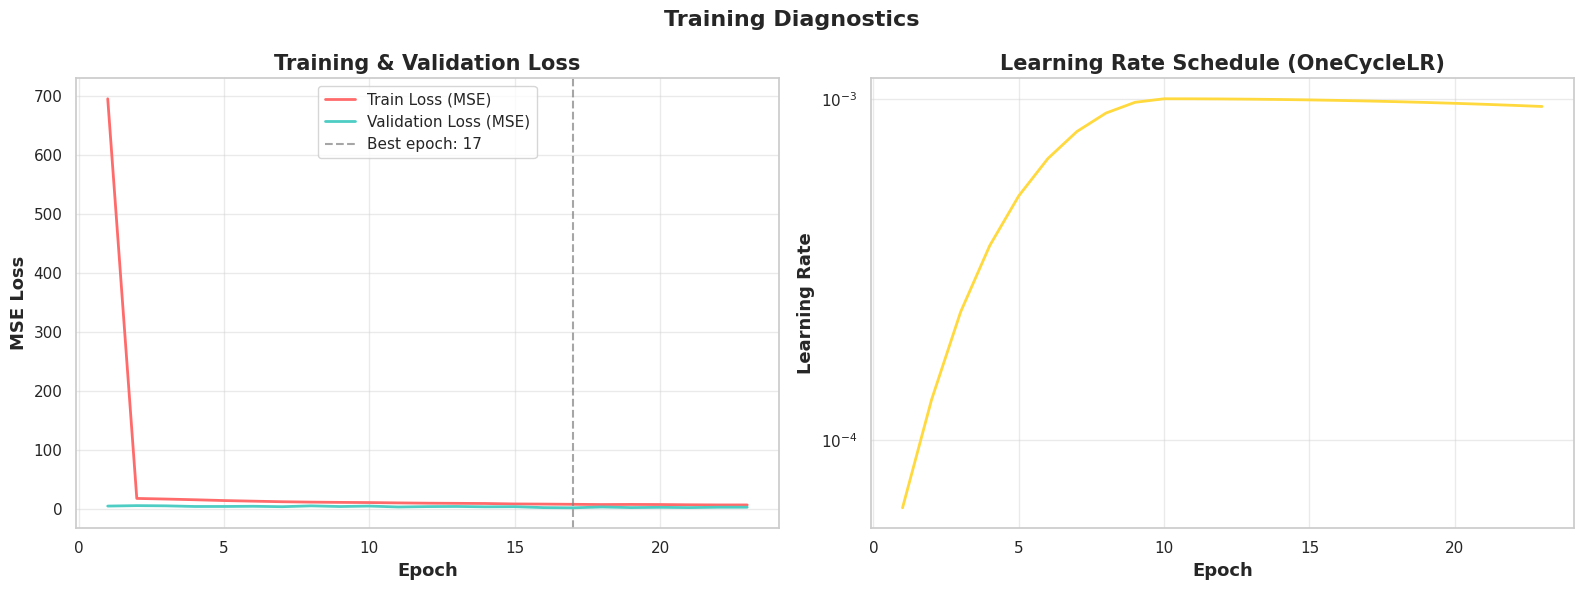

Best Val Loss: 1.9366 at epoch 17
Final Train Loss: 6.7804
Final Val Loss:   2.9169


In [21]:
# ─────────────────────────────────────────────
# SECTION 11: Training Curves
# ─────────────────────────────────────────────
# Note: train_losses / val_losses / learning_rates are either from the
# current run OR loaded from checkpoint — both cases are handled.

epochs_range = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: Train vs Val Loss ──
axes[0].plot(epochs_range, train_losses, label='Train Loss (MSE)',
             color='#FF6B6B', linewidth=2)
axes[0].plot(epochs_range, val_losses, label='Validation Loss (MSE)',
             color='#4ECDC4', linewidth=2)
axes[0].set_title('Training & Validation Loss', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=13, fontweight='bold')
axes[0].set_ylabel('MSE Loss', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.4)

# Mark best epoch (lowest val loss)
best_epoch = int(val_losses.index(min(val_losses))) + 1
axes[0].axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.7,
                label=f'Best epoch: {best_epoch}')
axes[0].legend(fontsize=11)

# ── Plot 2: Learning Rate Schedule ──
axes[1].plot(epochs_range, learning_rates, color='#FFD93D', linewidth=2)
axes[1].set_title('Learning Rate Schedule (OneCycleLR)', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Learning Rate', fontsize=13, fontweight='bold')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.4)

plt.suptitle('Training Diagnostics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=300)
plt.show()

print(f"Best Val Loss: {min(val_losses):.4f} at epoch {best_epoch}")
print(f"Final Train Loss: {train_losses[-1]:.4f}")
print(f"Final Val Loss:   {val_losses[-1]:.4f}")


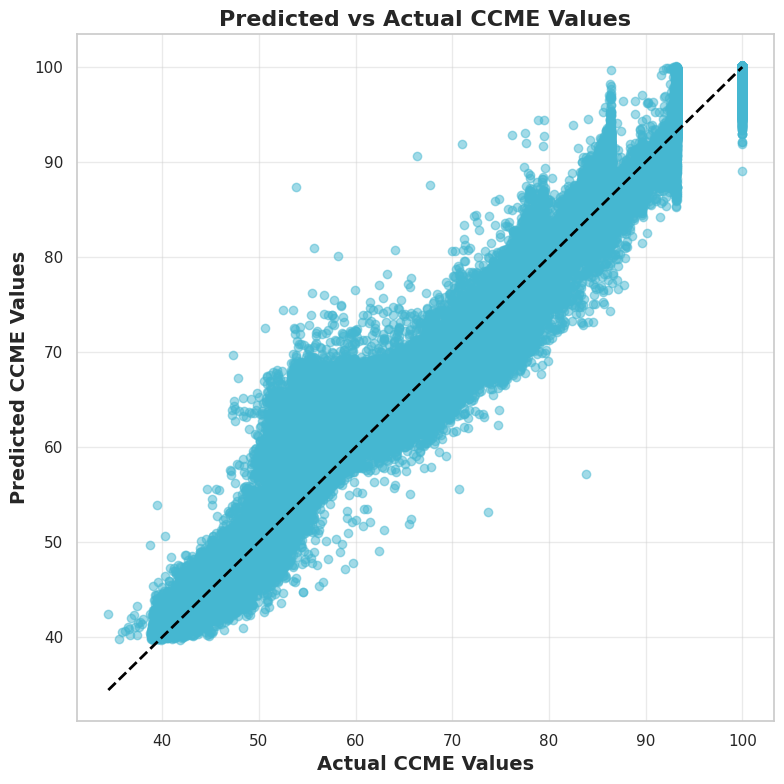

In [22]:

# ─────────────────────────────────────────────
# SECTION 12: Parity Plot (Predicted vs Actual)
# ─────────────────────────────────────────────
plt.figure(figsize=(8, 8))
plt.scatter(t_targets, t_preds, alpha=0.5, color='#45B7D1')
plt.plot([min(t_targets), max(t_targets)], [min(t_targets), max(t_targets)], color='black', linestyle='--', linewidth=2)
plt.title('Predicted vs Actual CCME Values', fontsize=16, fontweight='bold')
plt.xlabel('Actual CCME Values', fontsize=14, fontweight='bold')
plt.ylabel('Predicted CCME Values', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('parity_plot.png', dpi=300)
plt.show()



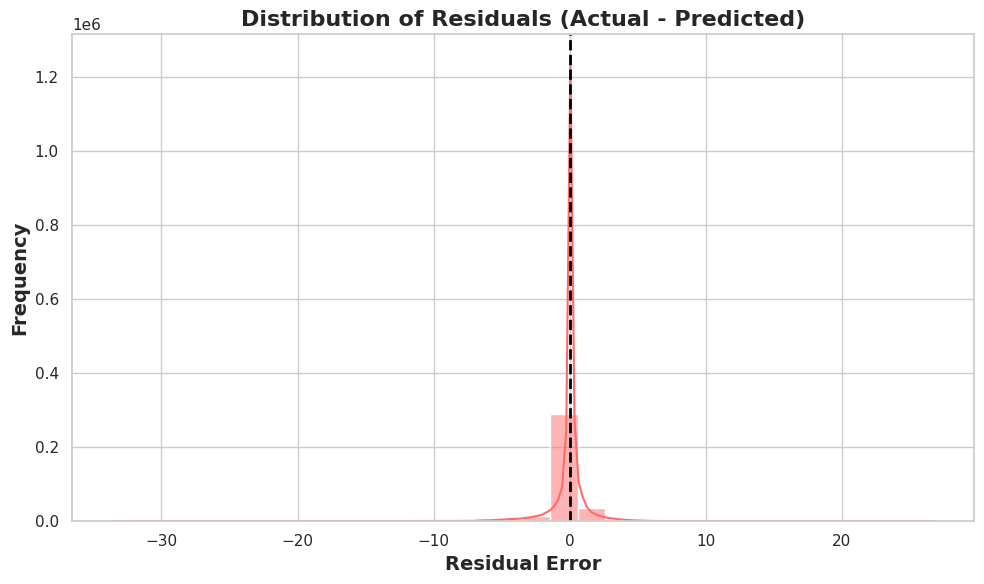

In [23]:

# ─────────────────────────────────────────────
# SECTION 13: Residual Distribution Plot
# ─────────────────────────────────────────────
residuals = t_targets - t_preds

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=30, color="#FF6B6B")
plt.axvline(x=0, color='black', linestyle='--', linewidth=2)
plt.title('Distribution of Residuals (Actual - Predicted)', fontsize=16, fontweight='bold')
plt.xlabel('Residual Error', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('residuals_plot.png', dpi=300)
plt.show()



In [24]:
# ─────────────────────────────────────────────
# SECTION 20: Final Summary
# ─────────────────────────────────────────────
print("\n" + "="*80)
print(" FINAL MODEL PERFORMANCE SUMMARY - CycleIFT Regression")
print("="*80)
print(f"  Test MSE:   {test_mse:>8.4f}")
print(f"  Test RMSE:  {test_rmse:>8.4f}")
print(f"  Test MAE:   {test_mae:>8.4f}")
print(f"  R2 Score:   {test_r2:>8.4f}")
print("="*80)



 FINAL MODEL PERFORMANCE SUMMARY - CycleIFT Regression
  Test MSE:     1.9816
  Test RMSE:    1.4077
  Test MAE:     0.6216
  R2 Score:     0.9927


In [25]:
# End of notebook - CycleIFT Regression on CCME_Values
